In [1]:
# from lakeshore import Model240, Model240InputParameter, Model240CurveHeader
import pynanovna
from pynanovna.utils import stream_from_csv
from pynanovna.vis import plot, polar
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import warnings
import time
import datetime
import os
from scipy.optimize import curve_fit
import warnings
import requests
import json
from edes.modules.detection.detection_utils import plot, plot_ax, plot_ax_errbar, plot_errbar, big_plt_font
big_plt_font()
warnings.filterwarnings('once')

import pyvisa as visa
from time import sleep
import matplotlib.pyplot as plt
import numpy as np
import time
from edes.modules.detection.detection_utils import plot, plot_ax, big_plt_font
import pandas as pd

big_plt_font()
rm = visa.ResourceManager()
## uncomment the following if full address not known
# instruments = rm.list_resources() 
# usb = list(filter(lambda x: 'USB' in x, instruments))
# print(usb)
keithley = rm.open_resource("USB0::1510::8448::1243106::0::INSTR")

# SSA = rm.open_resource(usb[1])
print(keithley.query("*IDN?"))

KEITHLEY INSTRUMENTS INC.,MODEL 2100,1,01.07-01-01


In [7]:
def read():
    raw_data = keithley.query(":READ?")
    resistance = float(raw_data.split(',')[0])
    return resistance

In [8]:
def query_temp(stage, T_to_channels = {'40K': 1, '4K': 2, '0.4K': 5}): 
    req = requests.get('http://192.168.169.102:5001/channel/measurement/latest', timeout=10)
    data = req.json()
    ch = T_to_channels[stage]
    while data['channel_nr'] != ch: 
        req = requests.get('http://192.168.169.102:5001/channel/measurement/latest', timeout=10)
        data = req.json()
    return data['temperature']

In [10]:
base = r'/home/electron/data/cooldown_05272026/resistor/'
os.makedirs(base, exist_ok=True)

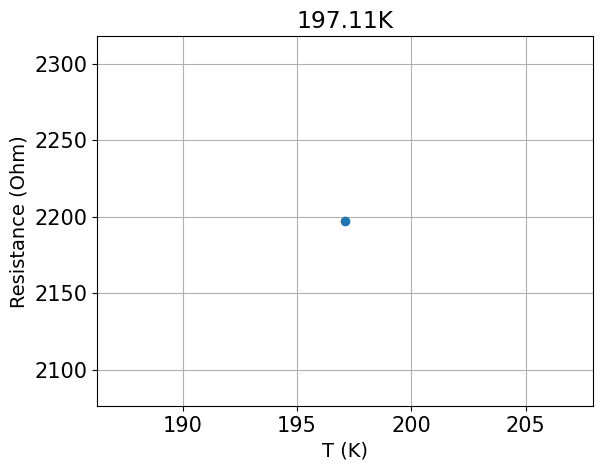

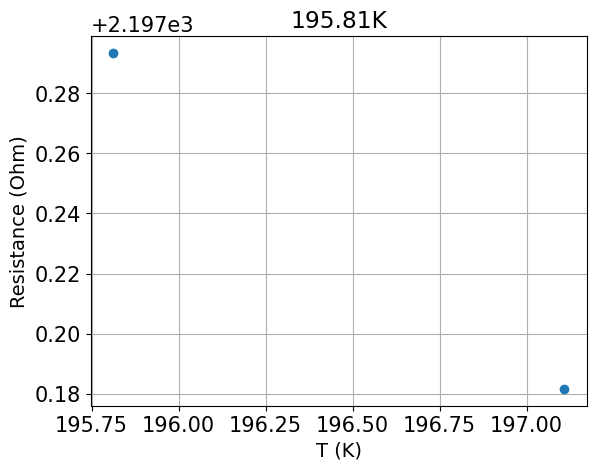

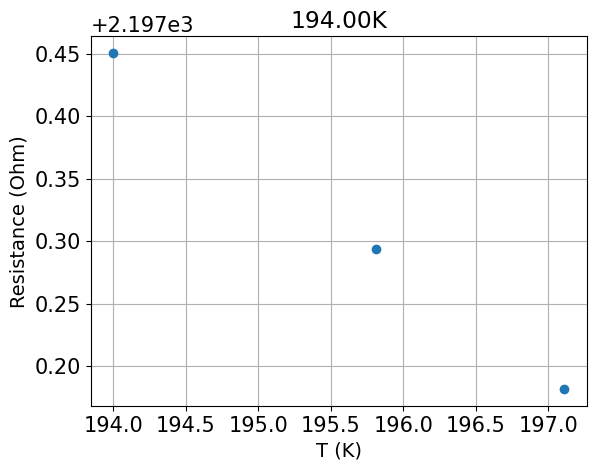

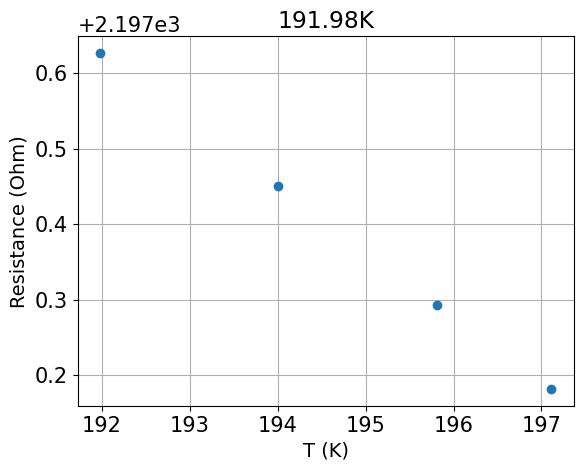

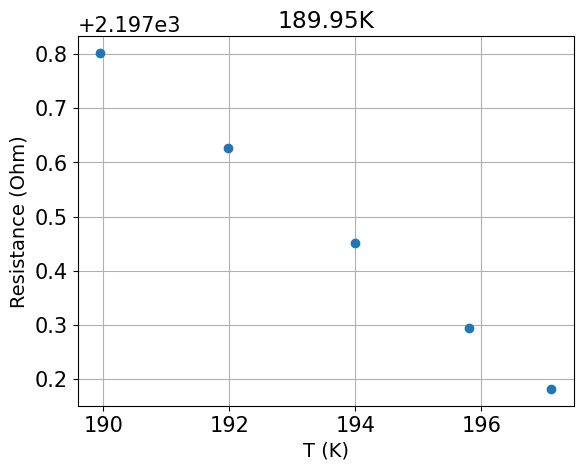

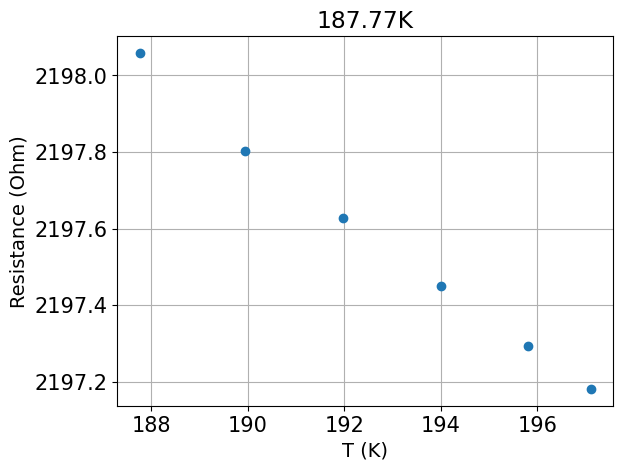

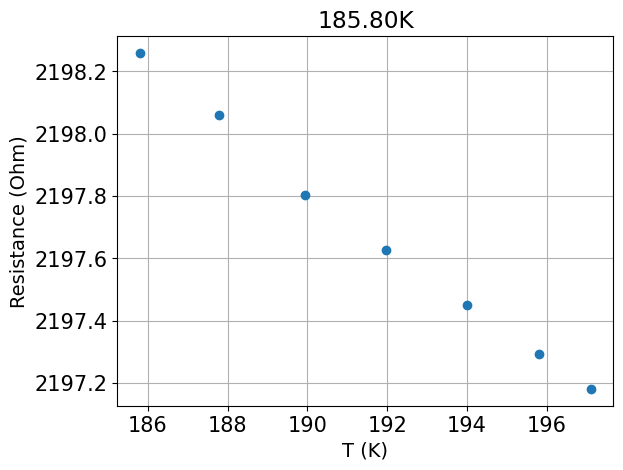

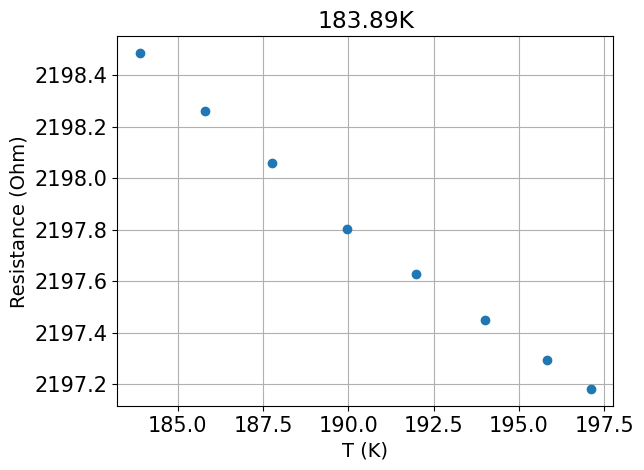

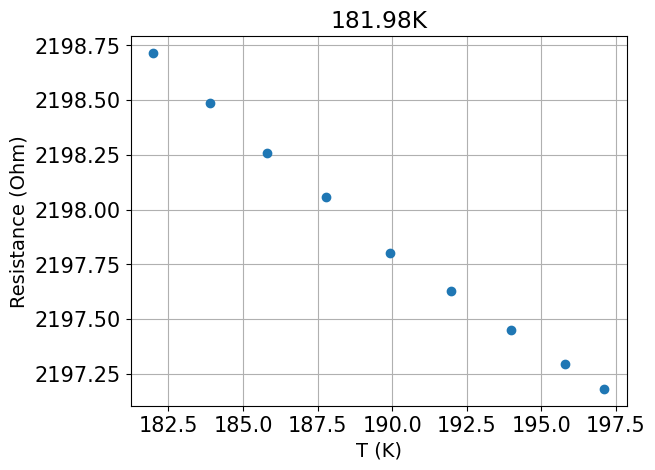

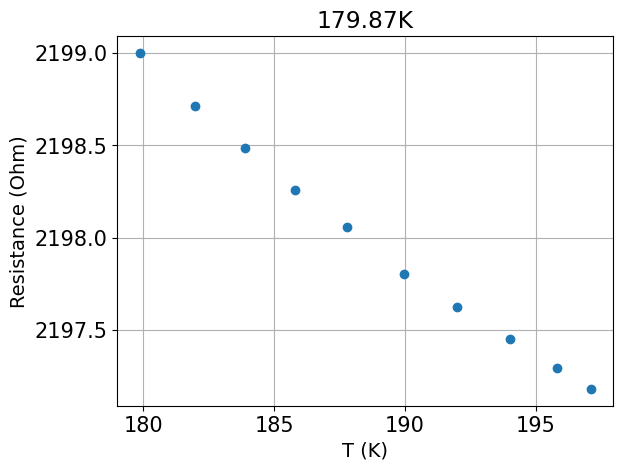

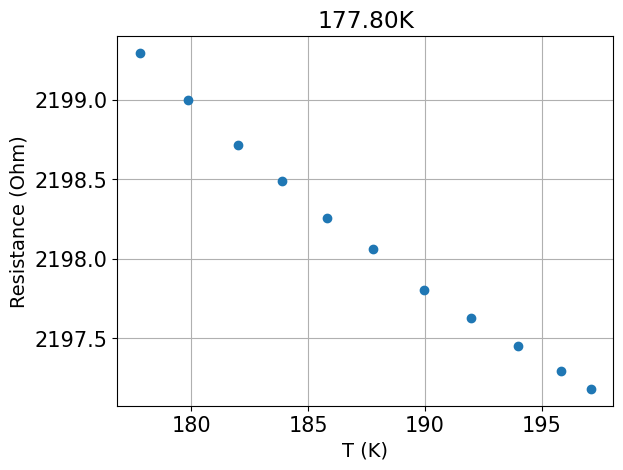

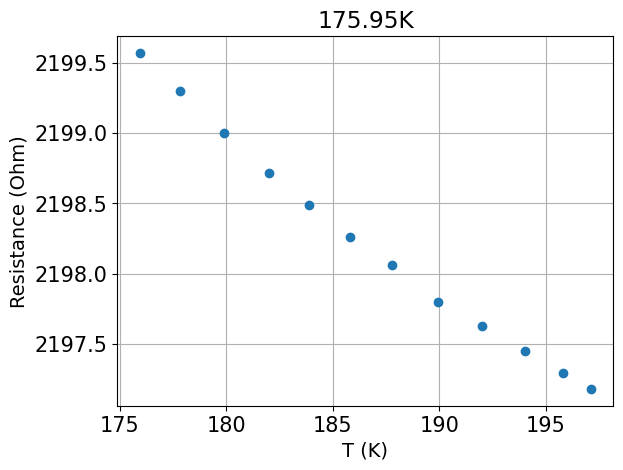

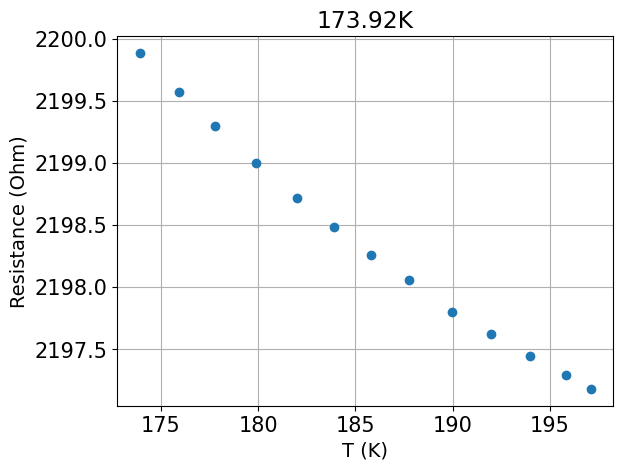

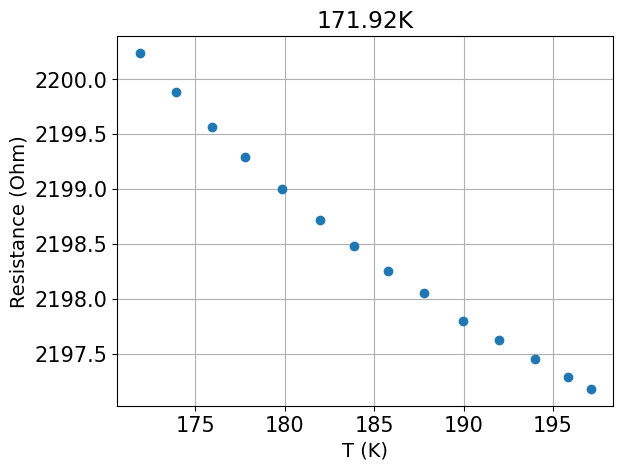

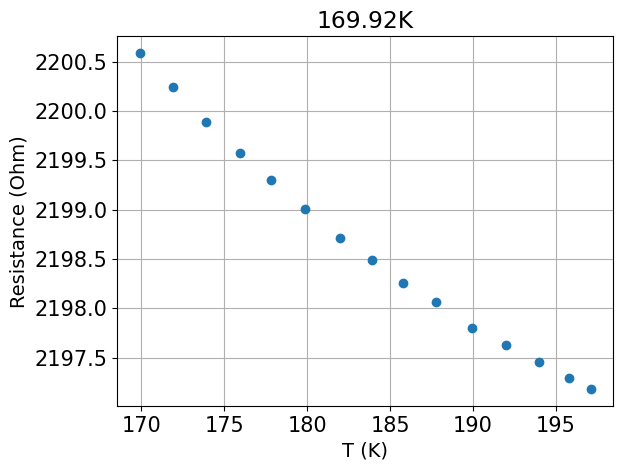

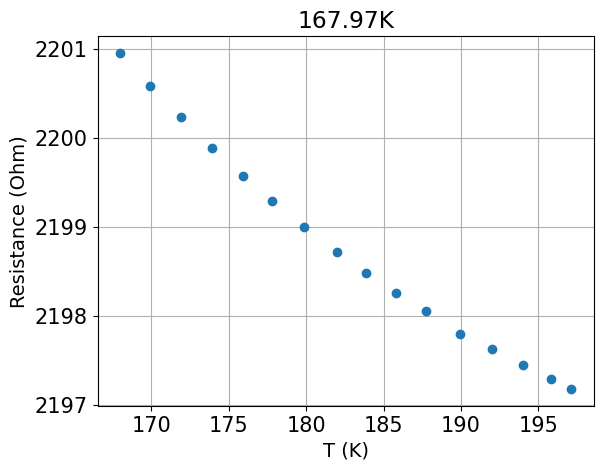

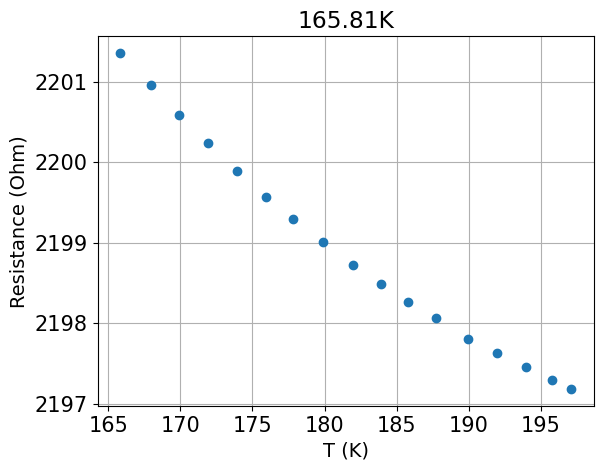

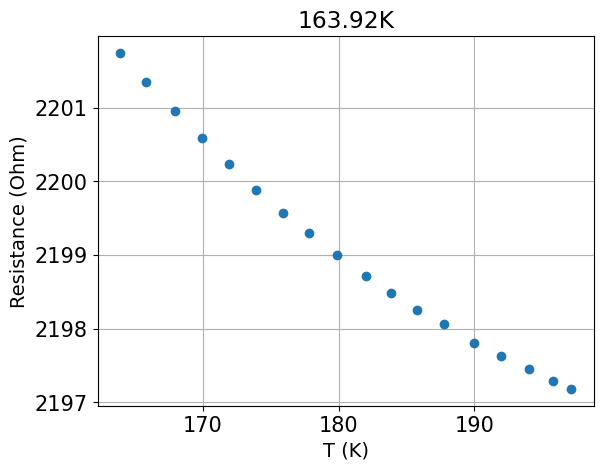

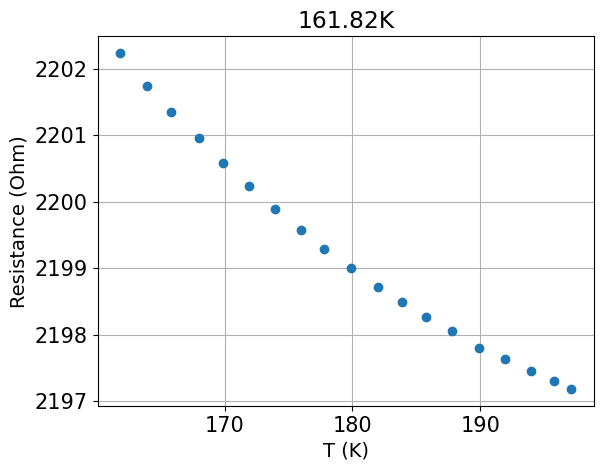

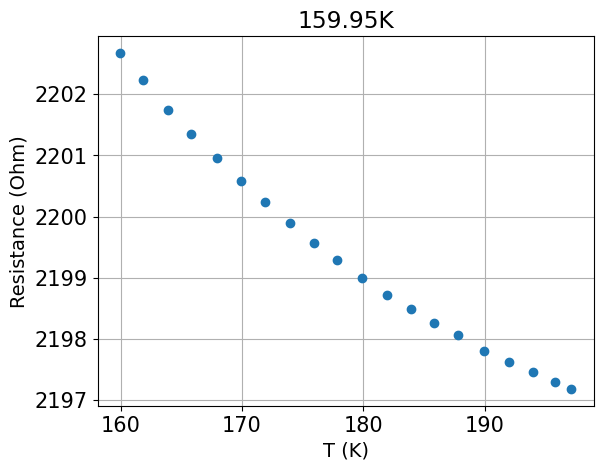

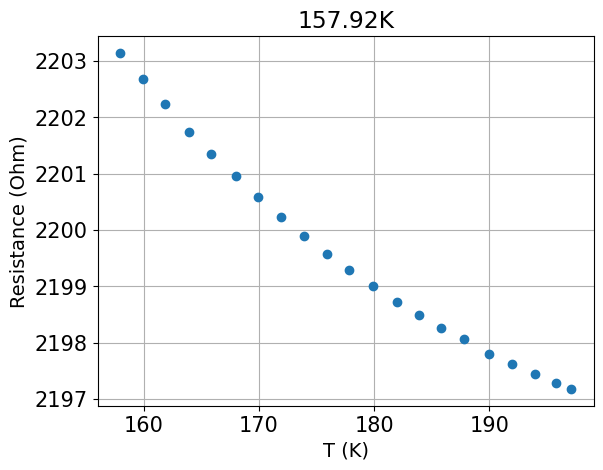

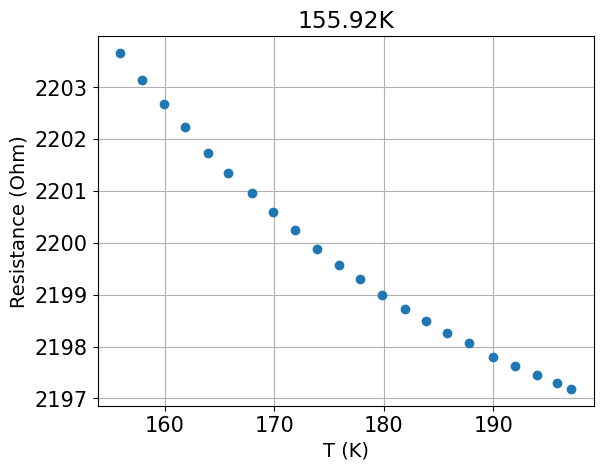

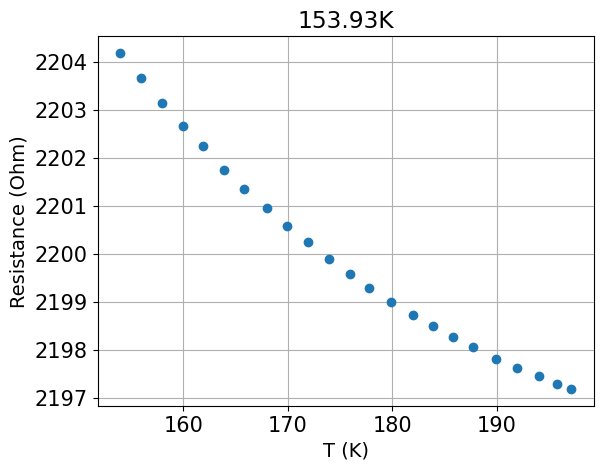

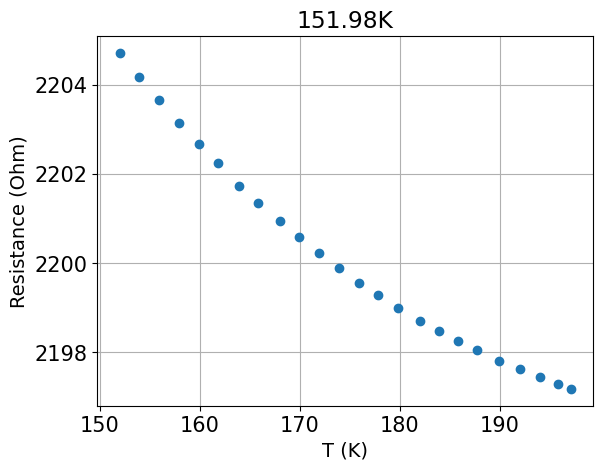

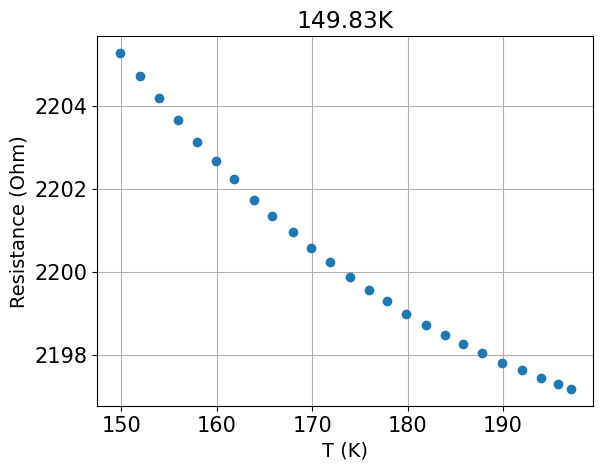

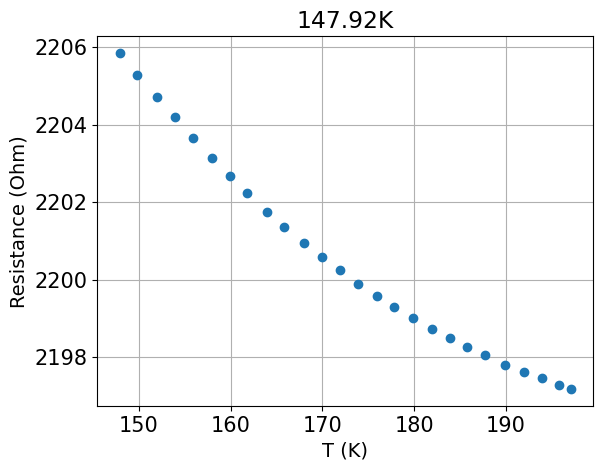

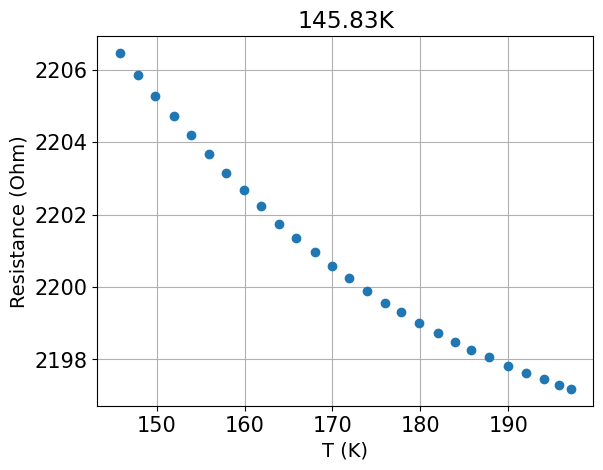

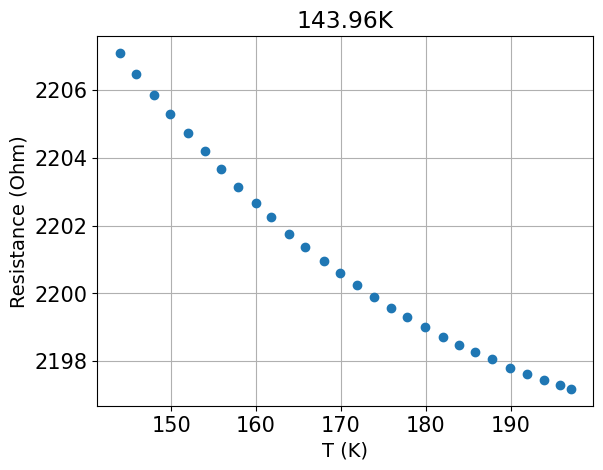

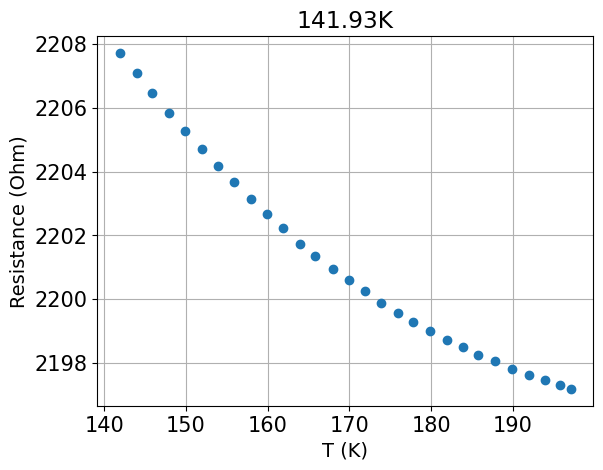

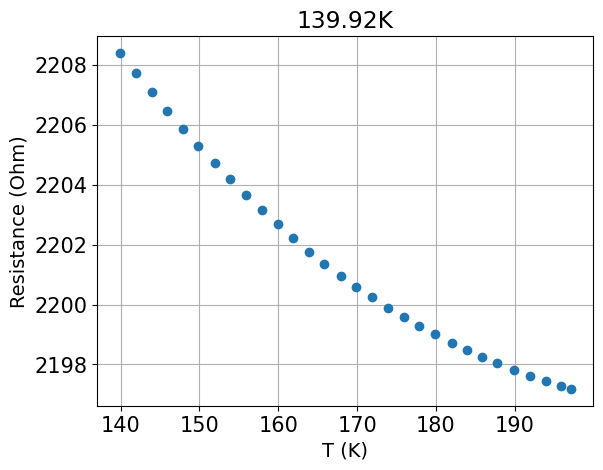

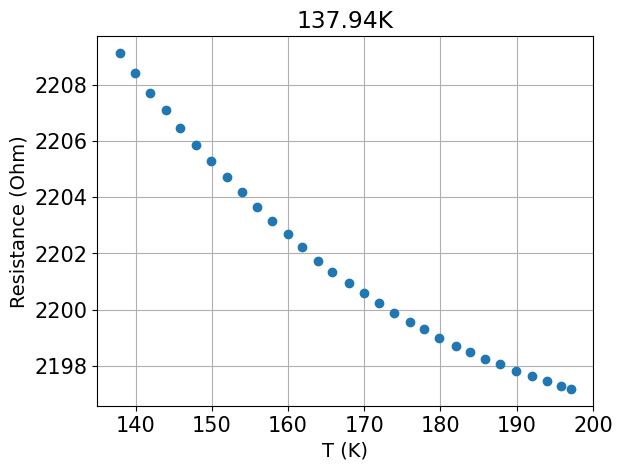

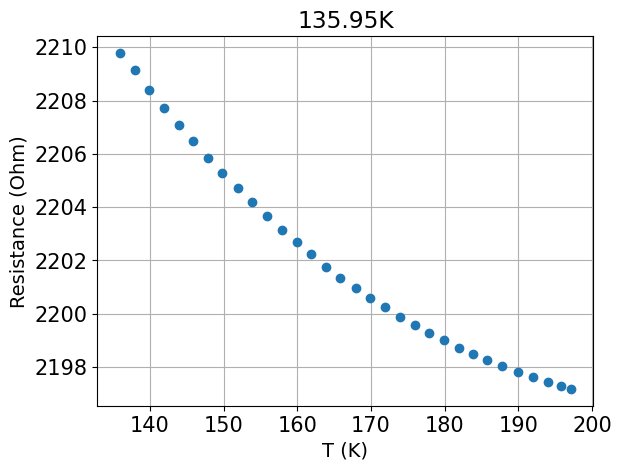

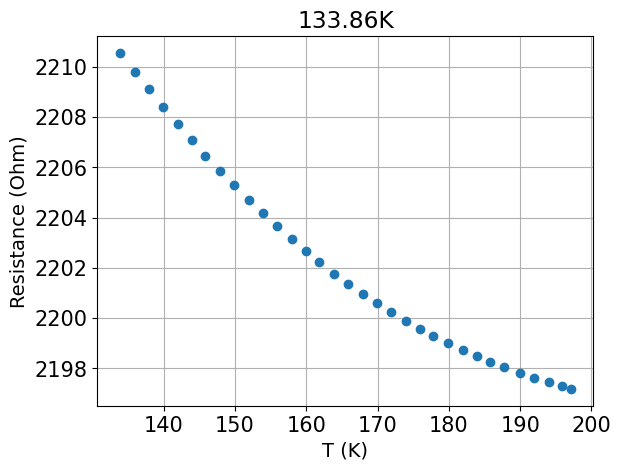

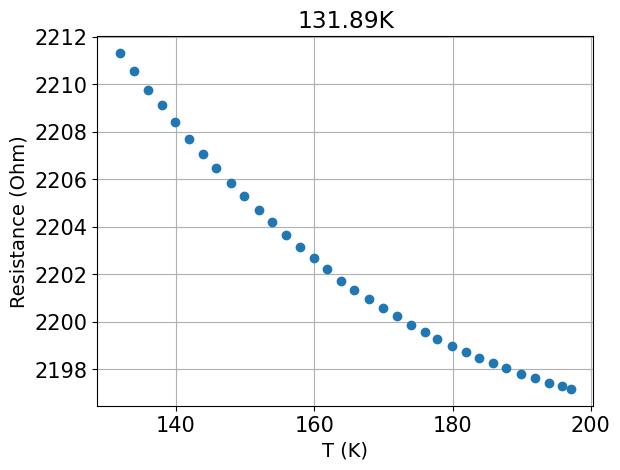

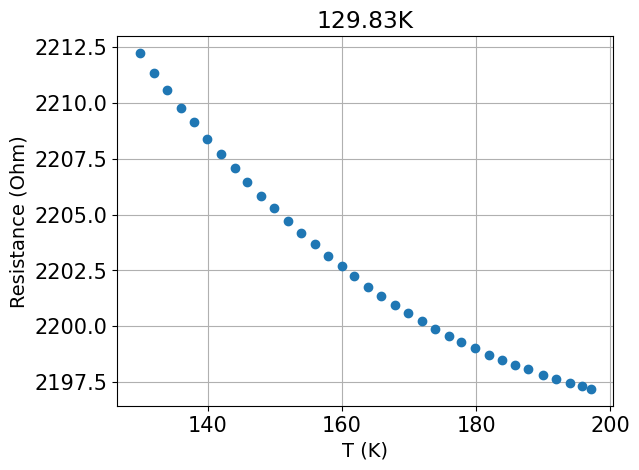

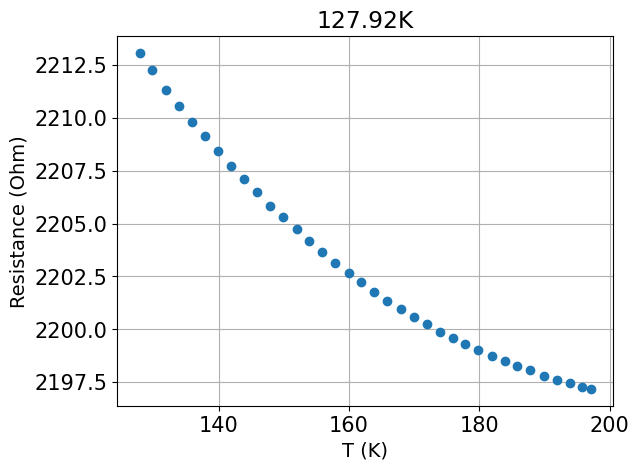

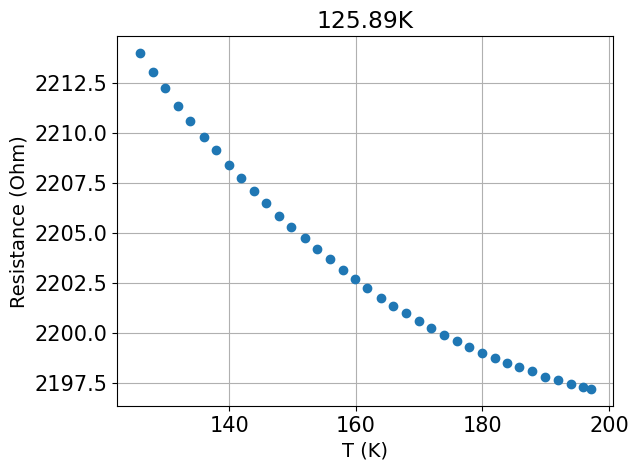

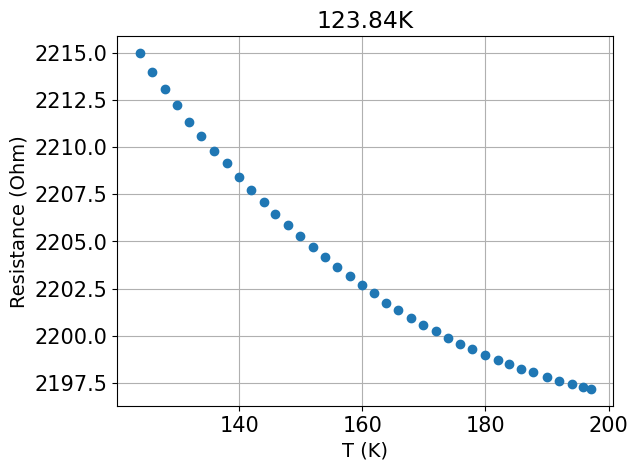

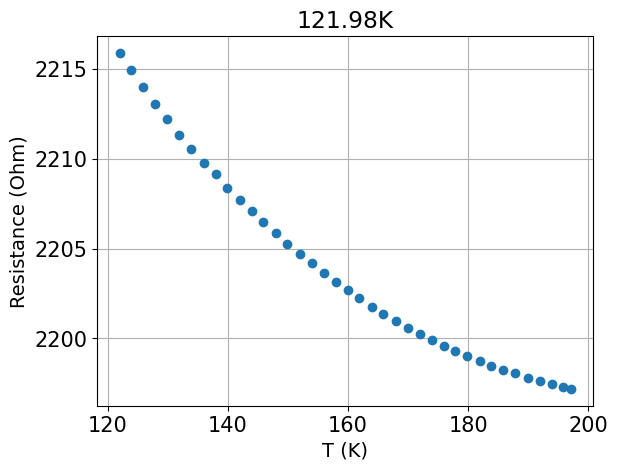

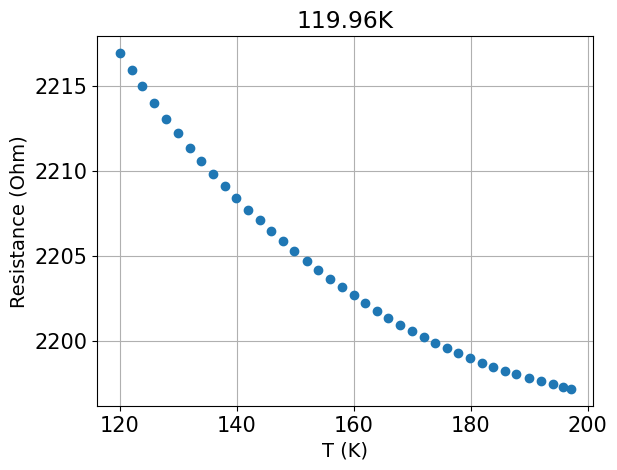

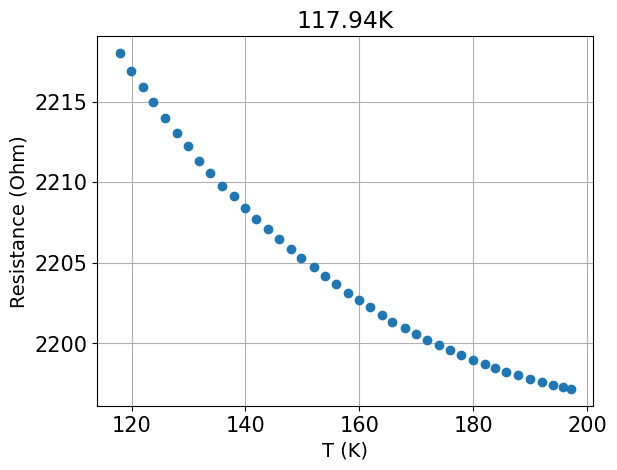

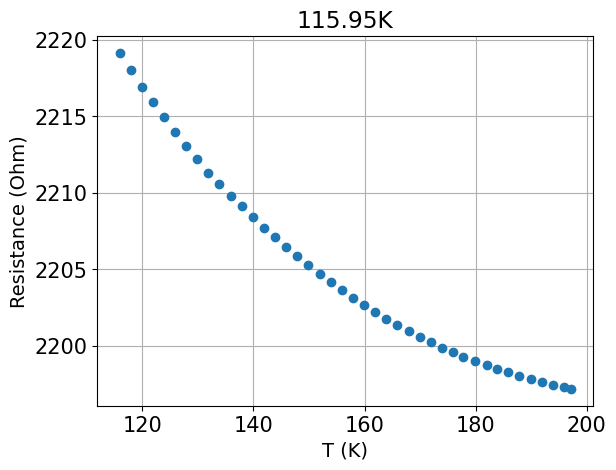

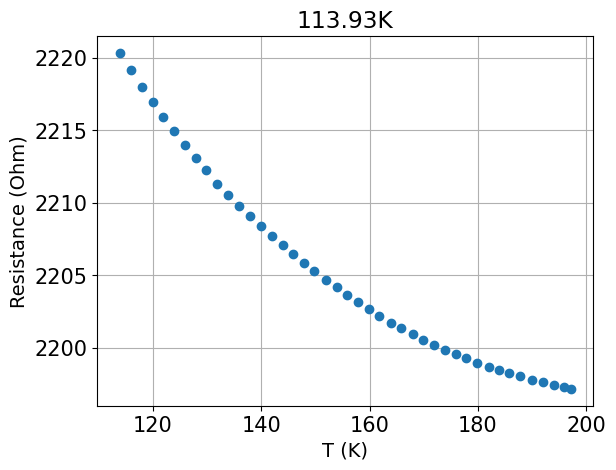

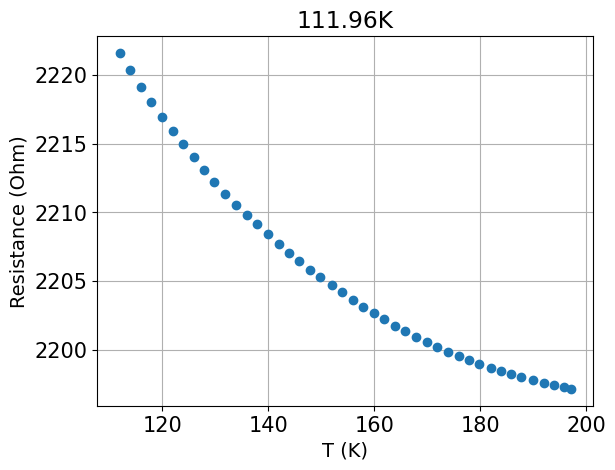

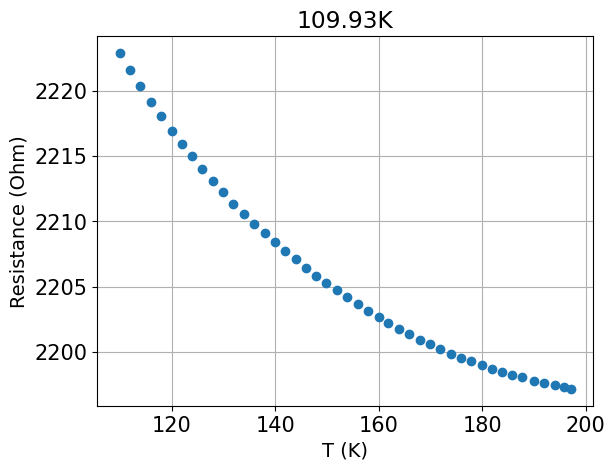

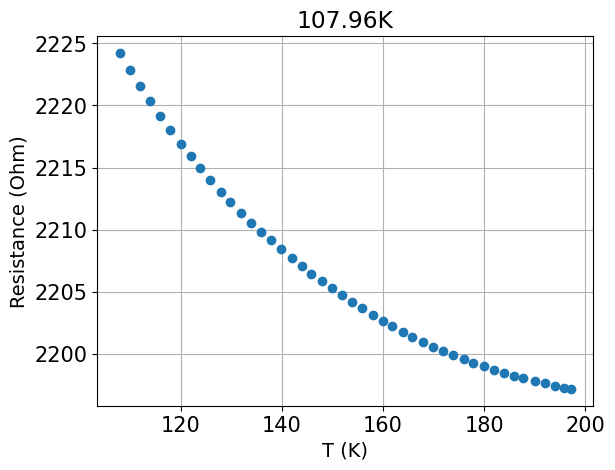

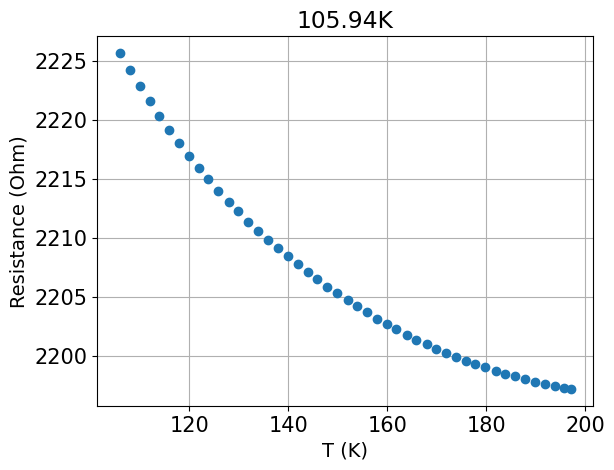

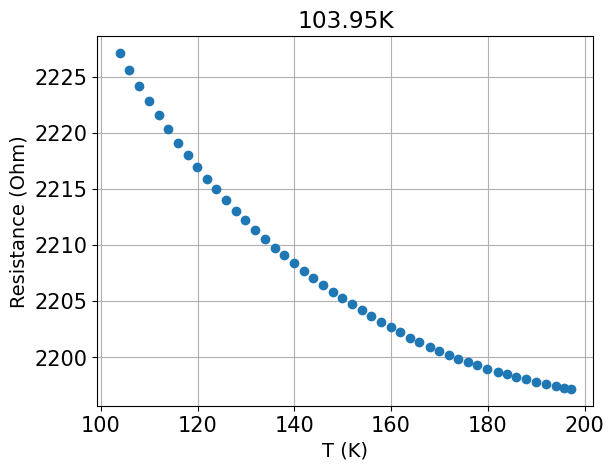

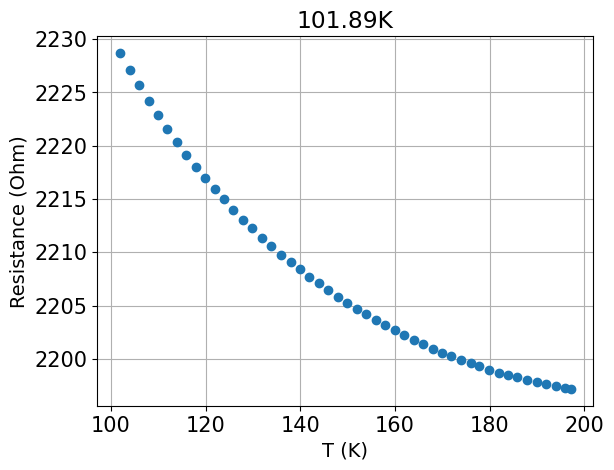

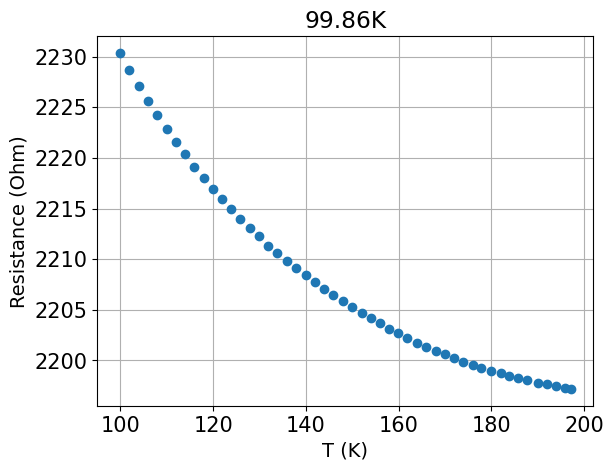

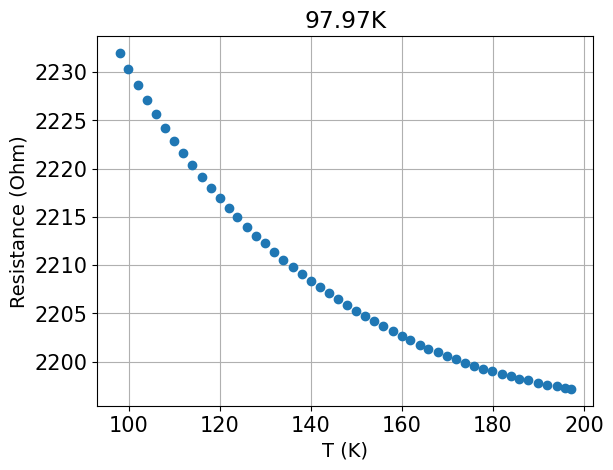

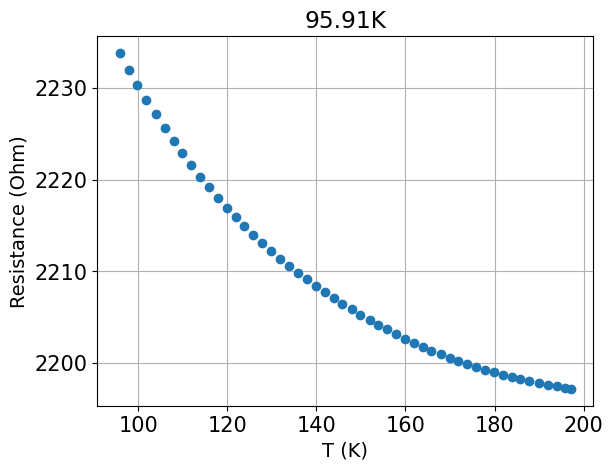

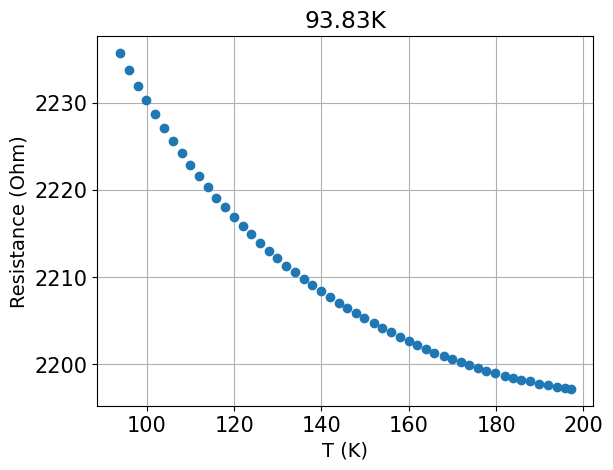

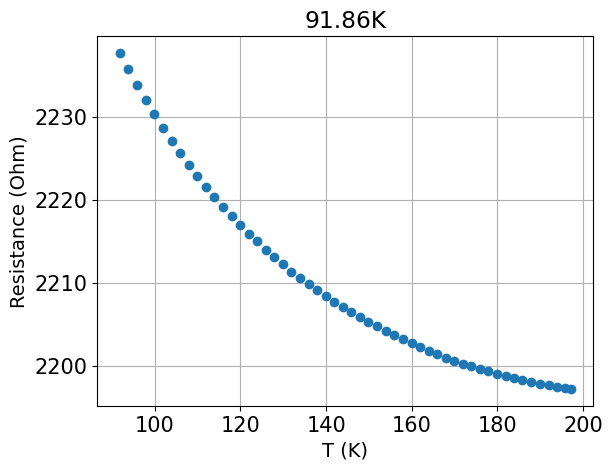

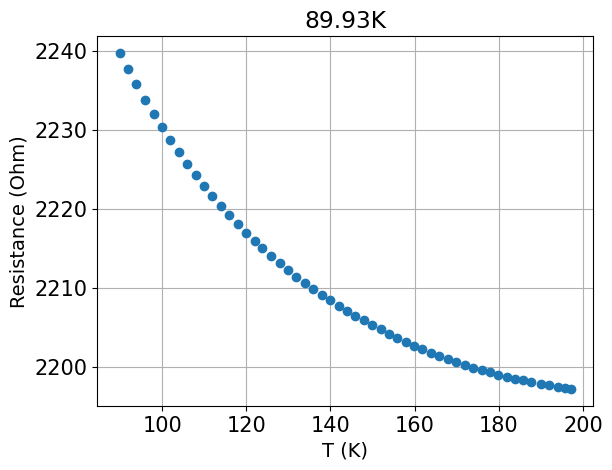

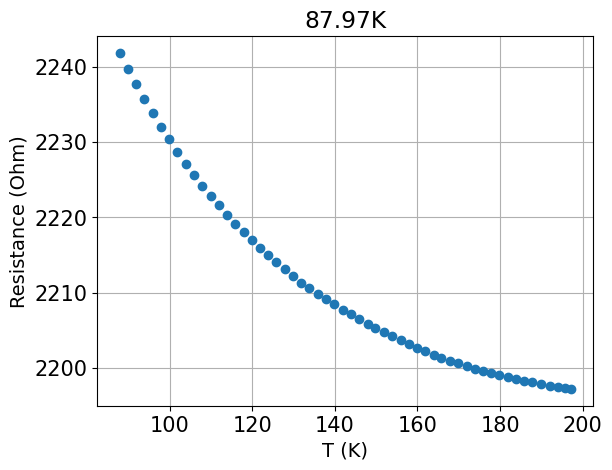

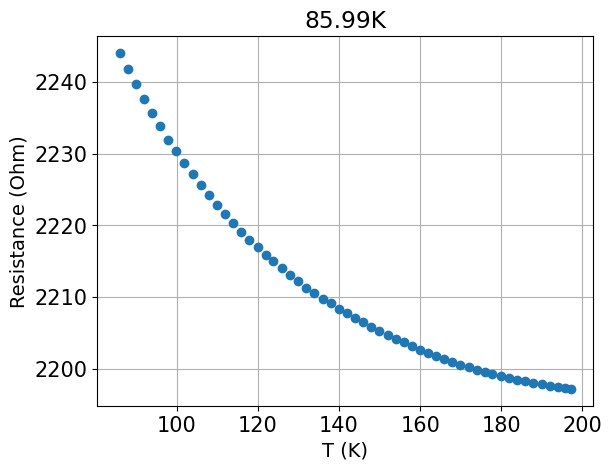

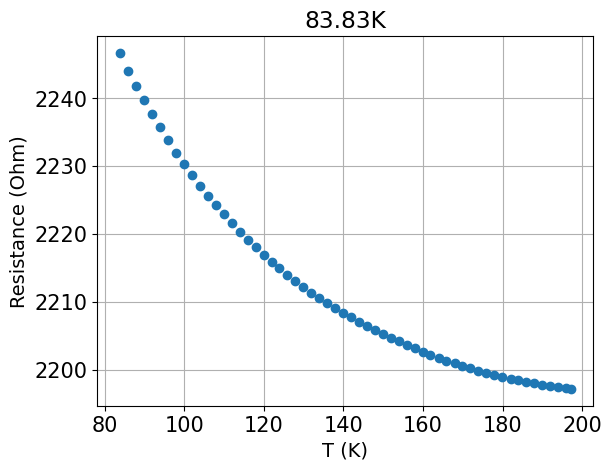

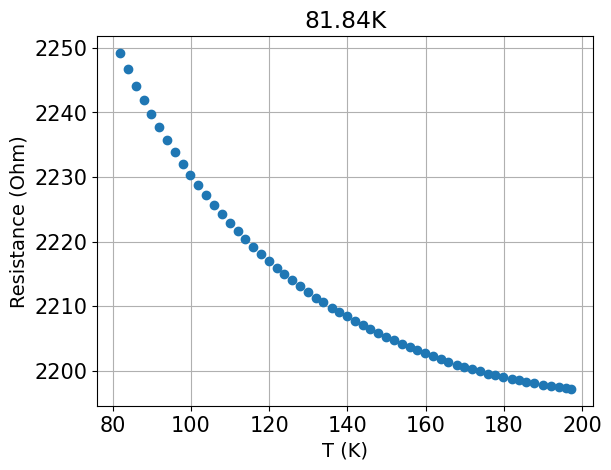

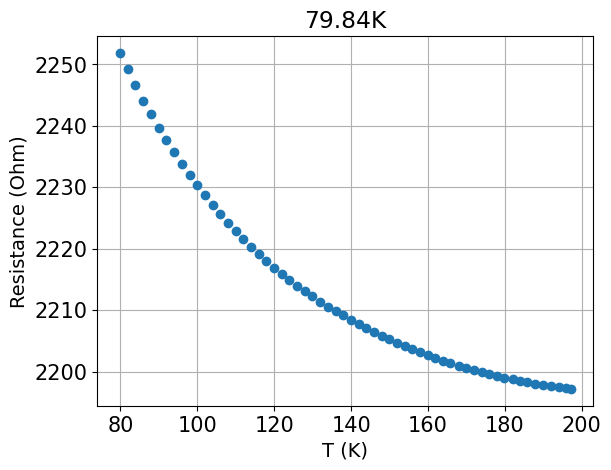

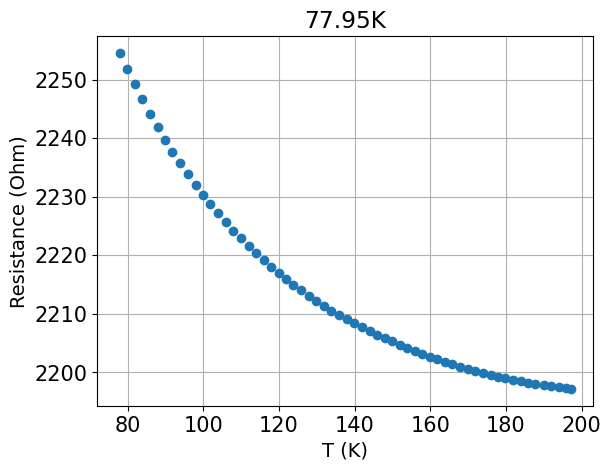

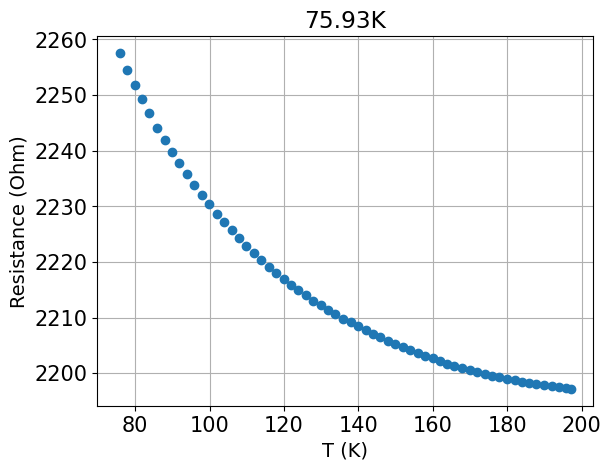

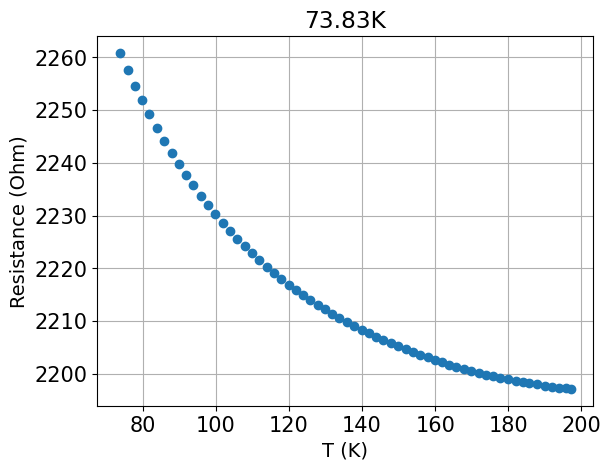

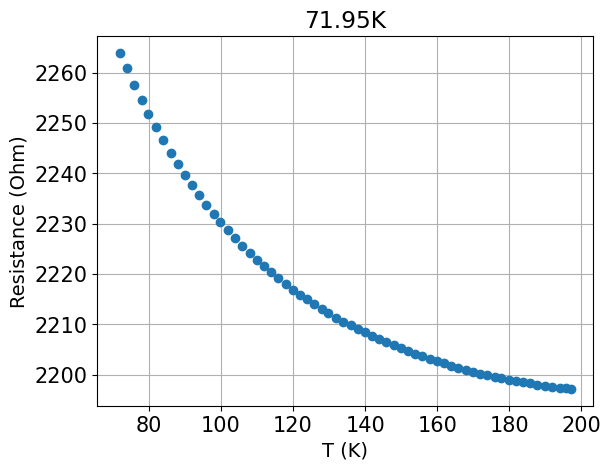

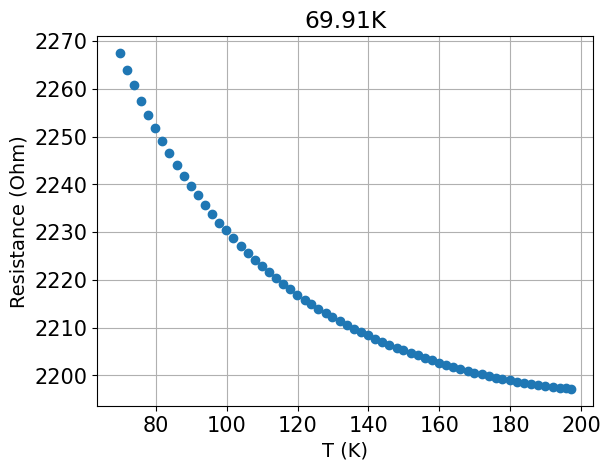

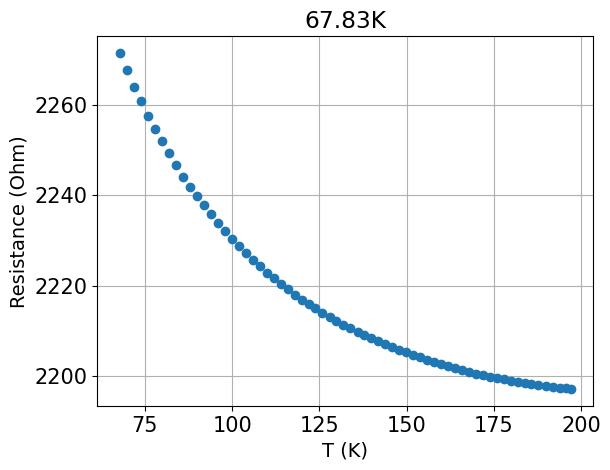

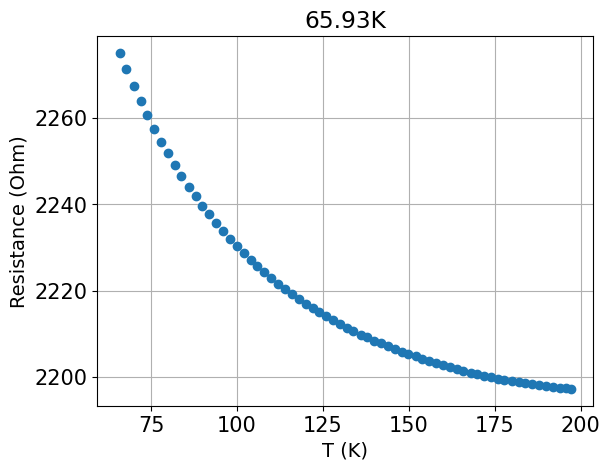

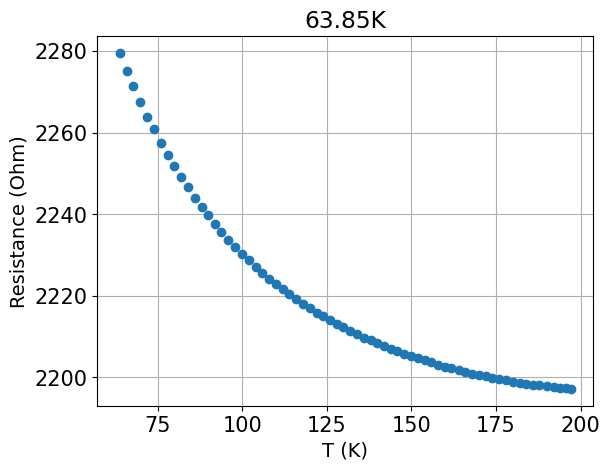

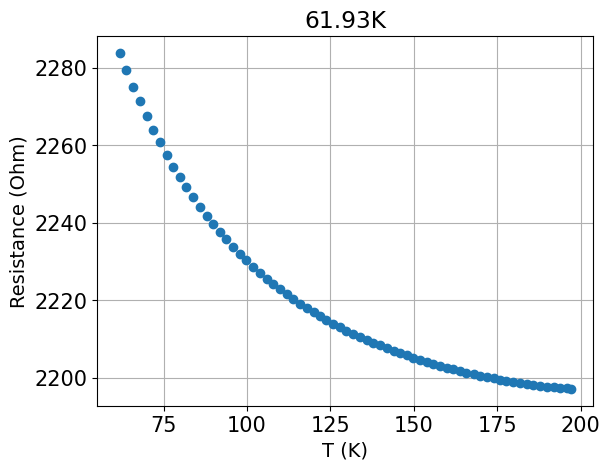

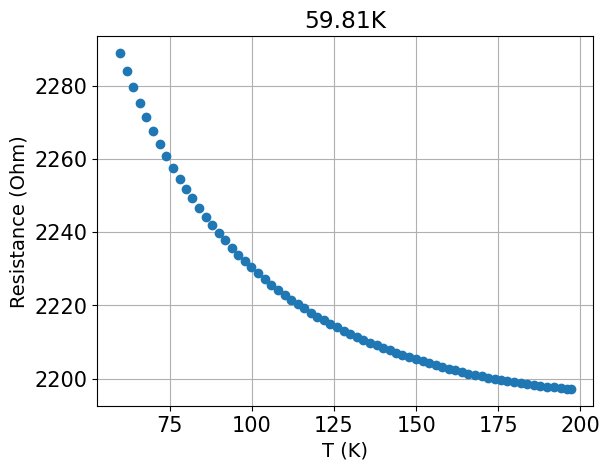

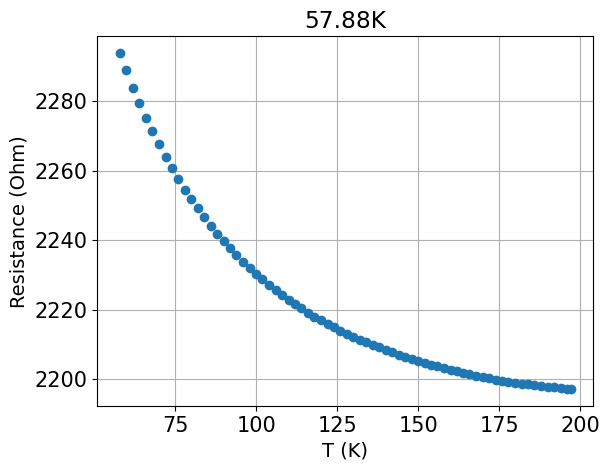

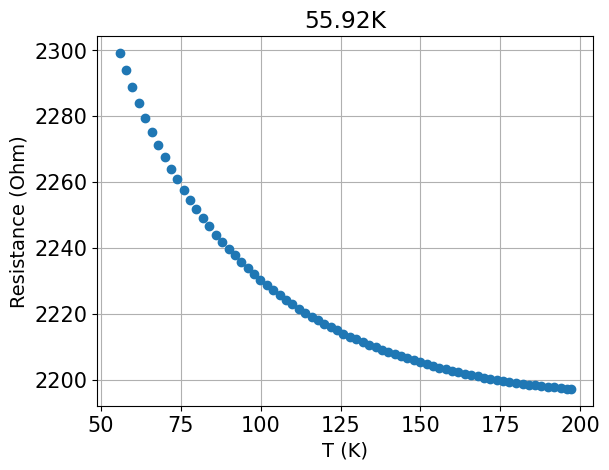

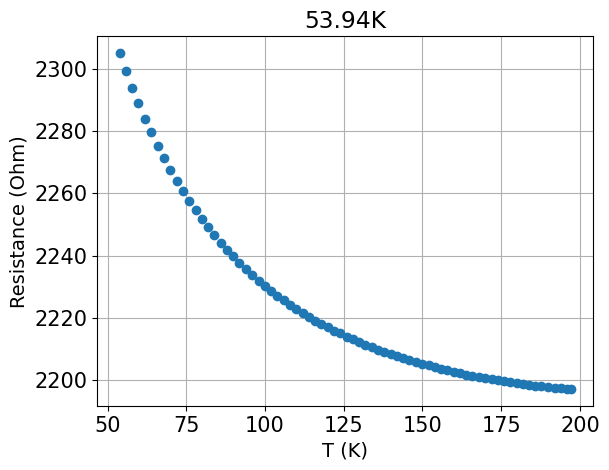

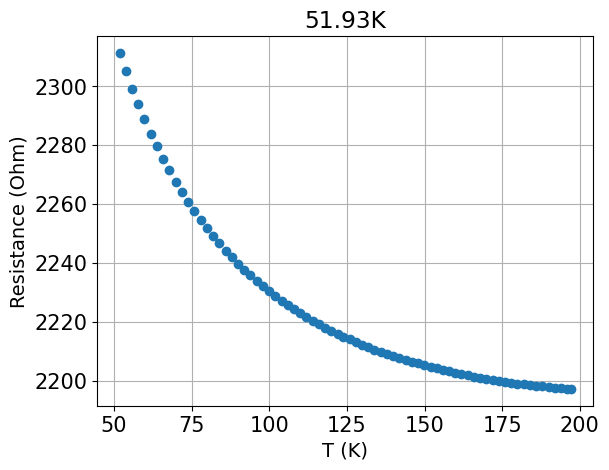

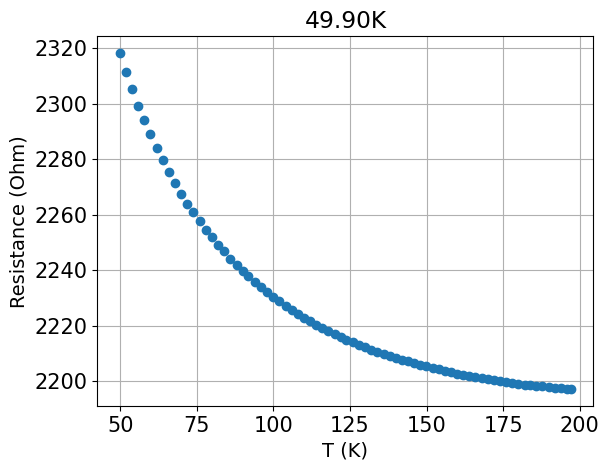

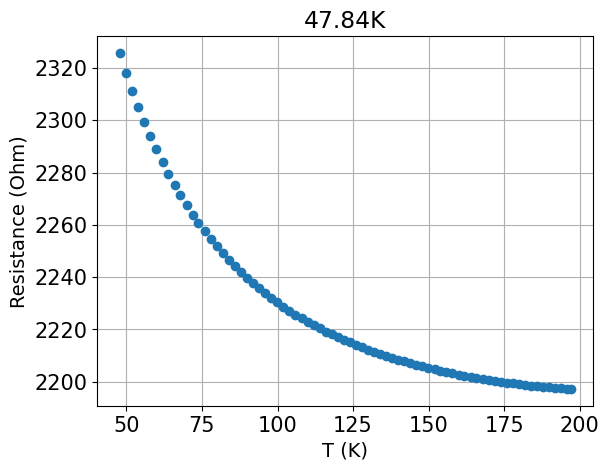

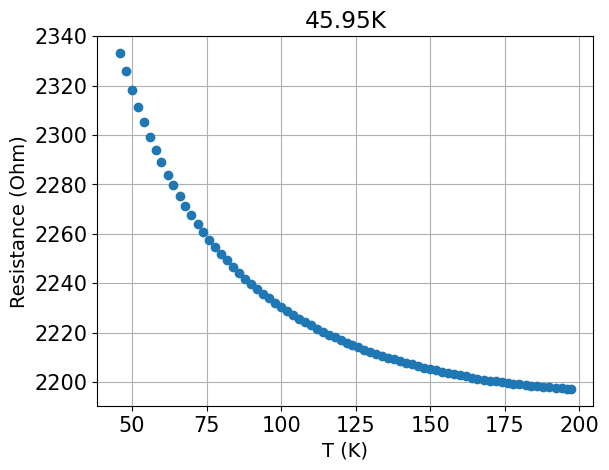

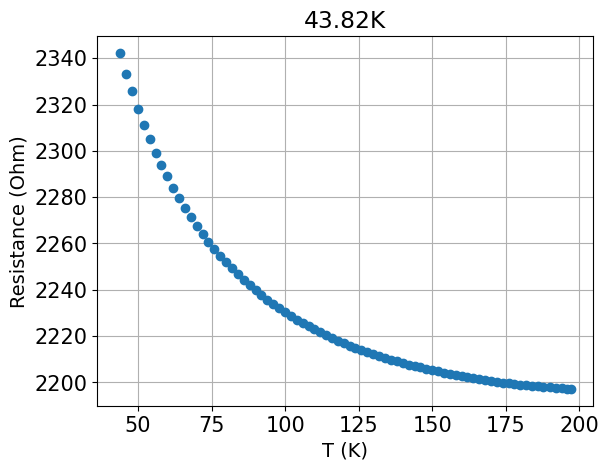

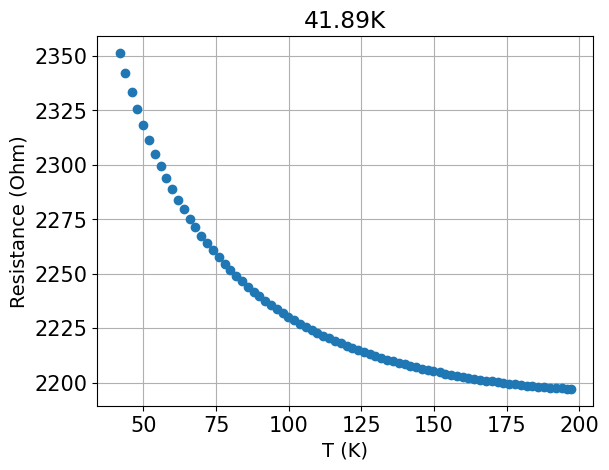

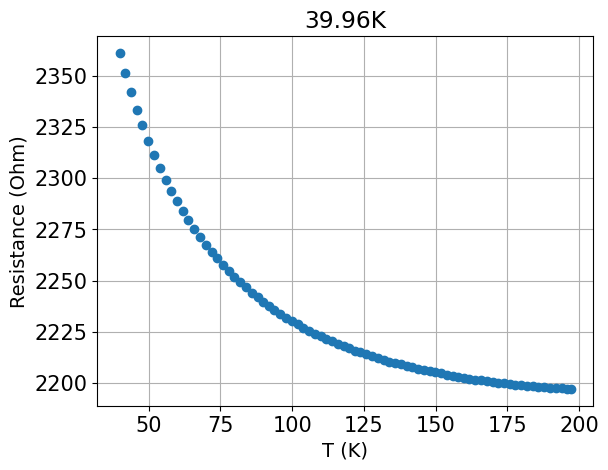

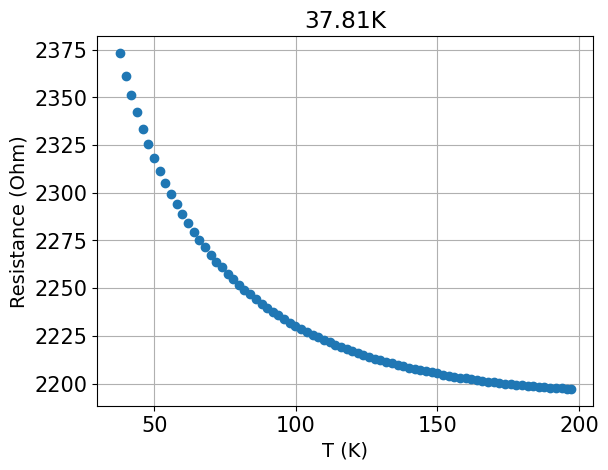

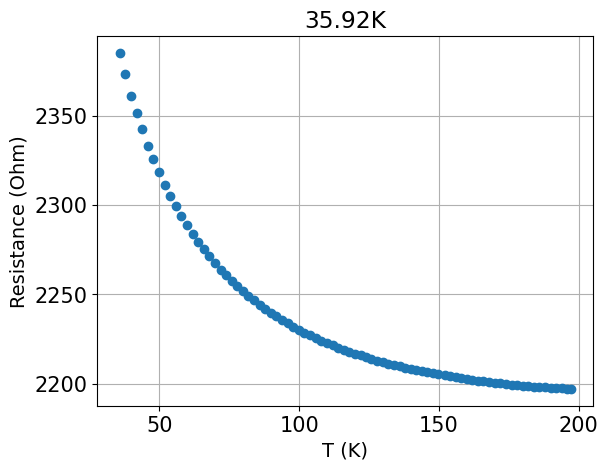

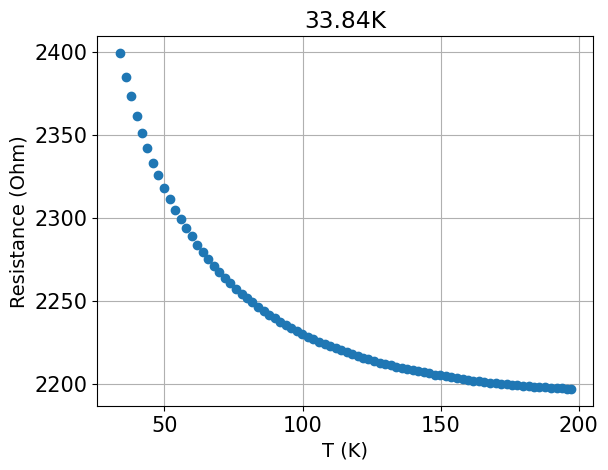

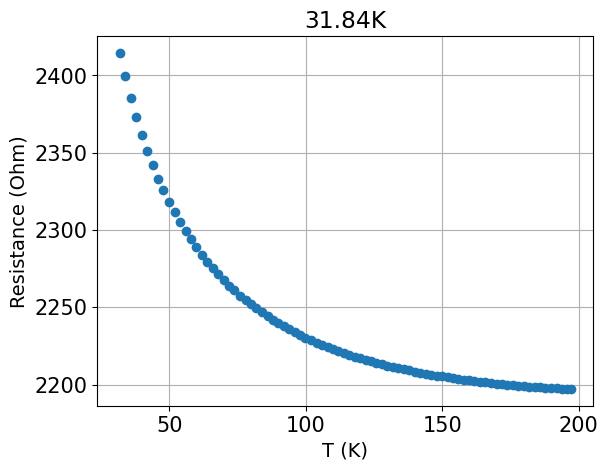

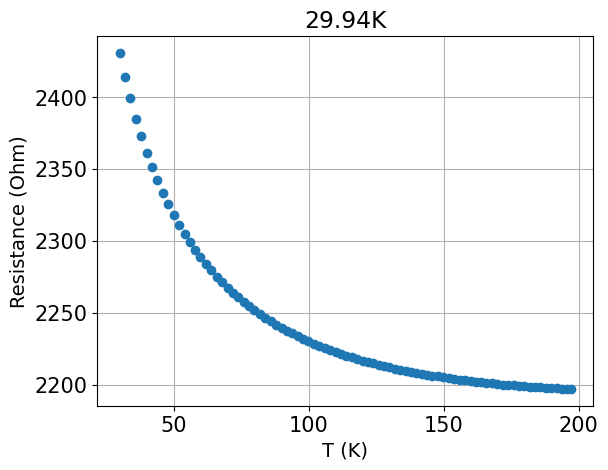

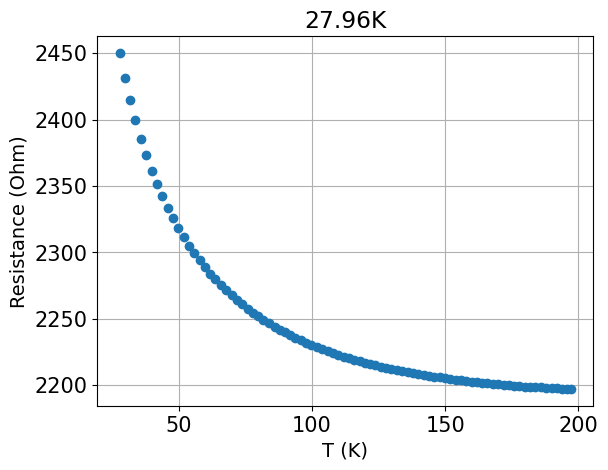

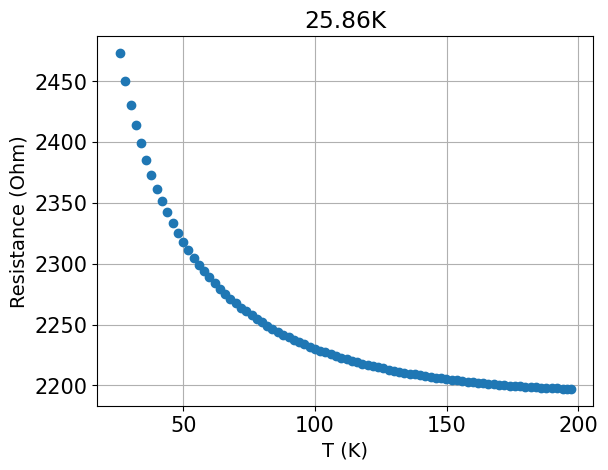

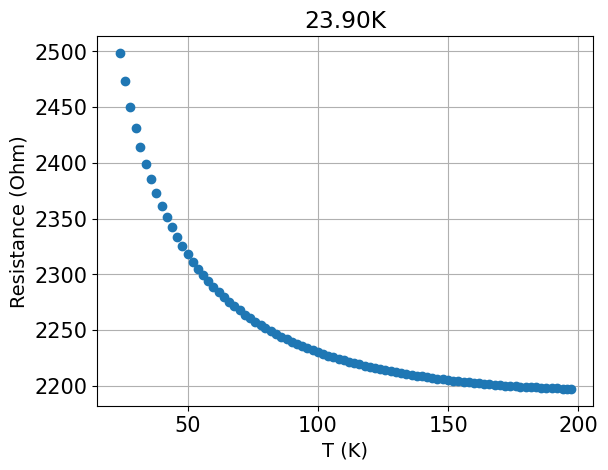

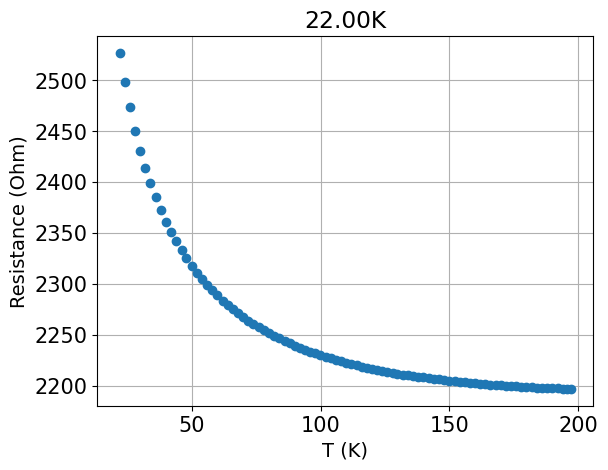

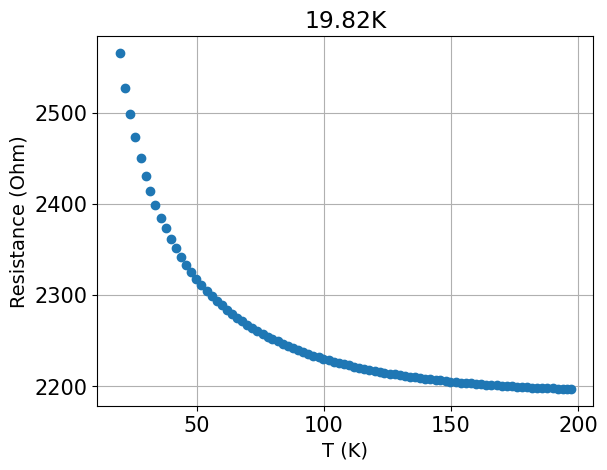

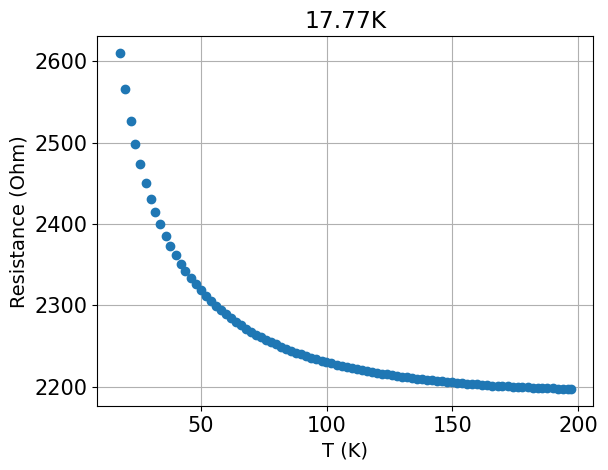

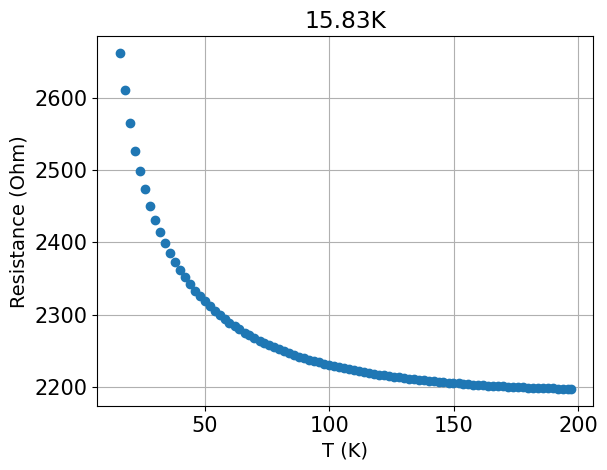

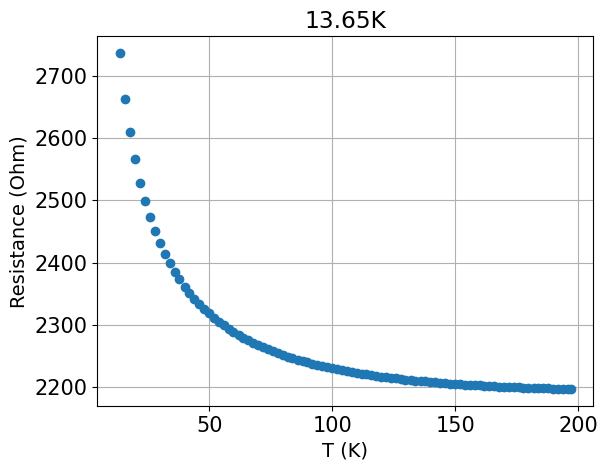

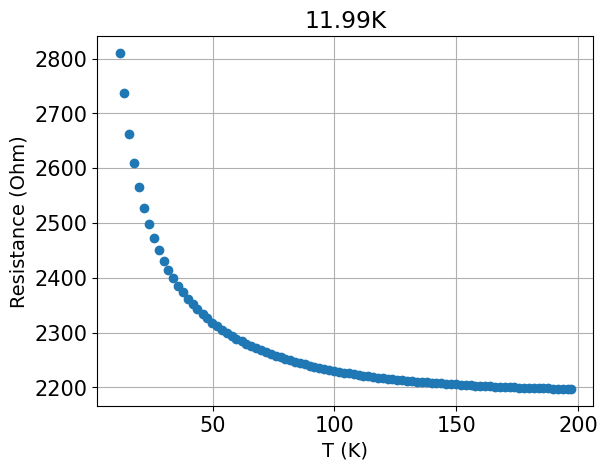

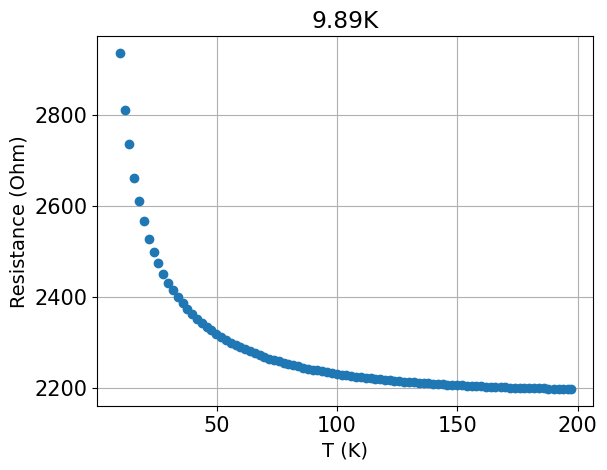

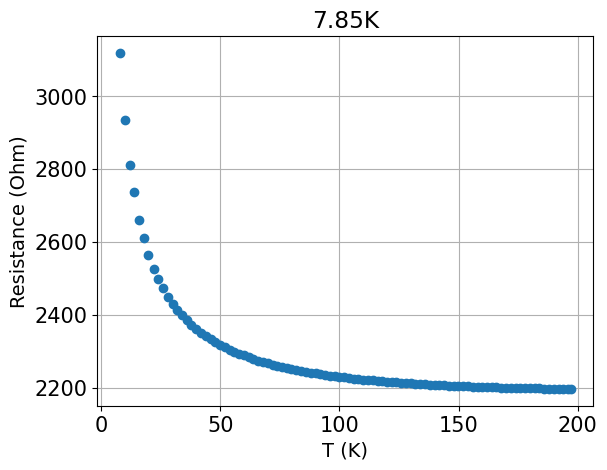

>>> Temperature cannot reach the desired 6K limit in 100 queries, current temperature 6.28K


In [12]:
folder_path = base #+ r'warmup_02192026_trap'
os.makedirs(folder_path, exist_ok=True)
temp_list = list(range(198,4,-2))
query_period = 15 # s 
timeout_0 = 100 # N x query period
R_list = [] 
T_list = []
timeout = timeout_0
curr_T_i = 0 
while curr_T_i < len(temp_list) and timeout > 0: 
    curr_T = query_temp("0.4K") 
    if curr_T <= temp_list[curr_T_i]: 
        filename = f'{curr_T}'
        try:
            R = read()
            R_list.append(R) 
            T_list.append(curr_T)
            plot(T_list, R_list, '.', xlabel='T (K)', ylabel='Resistance (Ohm)', title=f'{curr_T:.2f}K')
            plt.show()
            curr_T_i += 1 
            timeout = timeout_0
            np.savez(folder_path+filename, R=R_list, T=T_list)
        except: 
            print(">>> Serial exception caught, sleep for 1s and continuing")
            time.sleep(1)
    else: 
        time.sleep(query_period) 
        timeout -= 1
        if timeout == 0: 
            print(f">>> Temperature cannot reach the desired {temp_list[curr_T_i]}K limit in {timeout_0} queries, current temperature {curr_T:.2f}K")